# 05 - Neural Network\n\nRede neural em PyTorch sobre uma amostra da silver. O objetivo aqui e capacidade preditiva, nao throughput distribuido.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/notebooks')

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from _lib import (
    build_spark, append_metric,
    SEED, SPLIT_DATE, SILVER_PATH, TARGET_COL,
    NUMERIC_COLS, CATEGORICAL_COLS,
)

MODEL_OUTPUT = Path('/models/neural_network.pt')
RESIDUAL_PLOT = Path('/results/residual_analysis_neural_network.png')

RAW_CONTEXT_COLS = ['pu_borough', 'trip_length', TARGET_COL]
SAMPLE_COLS = list(dict.fromkeys(RAW_CONTEXT_COLS + NUMERIC_COLS + CATEGORICAL_COLS))

# 1.6M linhas estratificadas: mesmo volume do melhor run anterior,
# mas 533k por mes (Mar+Abr+Mai) em vez de 1.6M de Marco apenas.
# executor_memory='2g' / driver_memory='3g' confortavel na RAM de 8GB.
TRAIN_FRACTION = 0.10
TEST_FRACTION  = 0.02
MAX_TRAIN_ROWS = 1_600_000
MAX_TEST_ROWS  = 150_000
BATCH_SIZE = 8192
EPOCHS = 60
PATIENCE = 10
LEARNING_RATE = 1e-3
USE_LOG_TARGET = True

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

spark = build_spark('nyc-rideshare-neural-network', executor_memory='2g', driver_memory='3g')
sns.set_theme(style='whitegrid')
device

device(type='cpu')

In [2]:
silver_df = spark.read.parquet(SILVER_PATH)
silver_df.createOrReplaceTempView('trips_silver')

sample_cols_sql = ', '.join(SAMPLE_COLS)

# Amostragem estratificada por mes: evita o vies temporal que RAND+LIMIT simples
# introduz ao preencher a cota com os primeiros meses escaneados (Mar >> Abr >> Mai).
# Cada mes de treino (Mar-Mai) e de teste (Jun-Ago) contribui igualmente.
PER_MONTH_TRAIN = MAX_TRAIN_ROWS // 3   # ~833k por mes de treino
PER_MONTH_TEST  = MAX_TEST_ROWS // 3    # ~66.7k por mes de teste

train_spark = spark.sql(f"""
    (SELECT {sample_cols_sql} FROM trips_silver
     WHERE date >= '2023-03-01' AND date < '2023-04-01'
       AND RAND({SEED}) < 0.10 LIMIT {PER_MONTH_TRAIN})
    UNION ALL
    (SELECT {sample_cols_sql} FROM trips_silver
     WHERE date >= '2023-04-01' AND date < '2023-05-01'
       AND RAND({SEED}) < 0.10 LIMIT {PER_MONTH_TRAIN})
    UNION ALL
    (SELECT {sample_cols_sql} FROM trips_silver
     WHERE date >= '2023-05-01' AND date < '2023-06-01'
       AND RAND({SEED}) < 0.10 LIMIT {PER_MONTH_TRAIN})
""")
test_spark = spark.sql(f"""
    (SELECT {sample_cols_sql} FROM trips_silver
     WHERE date >= '2023-06-01' AND date < '2023-07-01'
       AND RAND({SEED + 1}) < 0.02 LIMIT {PER_MONTH_TEST})
    UNION ALL
    (SELECT {sample_cols_sql} FROM trips_silver
     WHERE date >= '2023-07-01' AND date < '2023-08-01'
       AND RAND({SEED + 1}) < 0.02 LIMIT {PER_MONTH_TEST})
    UNION ALL
    (SELECT {sample_cols_sql} FROM trips_silver
     WHERE date >= '2023-08-01' AND date < '2023-09-01'
       AND RAND({SEED + 1}) < 0.02 LIMIT {PER_MONTH_TEST})
""")

train_pdf = train_spark.toPandas()
test_pdf = test_spark.toPandas()

if train_pdf.empty or test_pdf.empty:
    raise ValueError('A NN exige dados antes e depois de 2023-06-01.')

test_context_pdf = test_pdf[RAW_CONTEXT_COLS].copy()

# Libera toda a JVM (driver + executors) antes do treino PyTorch.
# Com 8GB de RAM isso devolve ~3-4 GB para o processo Python.
spark.stop()

train_pdf.shape, test_pdf.shape

((1599999, 19), (150000, 19))

In [3]:
# Val split aleatorio (nao temporal) e proposital: o test set ja foi separado temporalmente.
# Aqui queremos so estimativa de loss para early stopping; nao se busca temporalidade dupla.
train_pdf, val_pdf = train_test_split(train_pdf, test_size=0.2, random_state=SEED)

train_pdf = pd.get_dummies(train_pdf, columns=CATEGORICAL_COLS, dummy_na=True)
val_pdf = pd.get_dummies(val_pdf, columns=CATEGORICAL_COLS, dummy_na=True)
test_pdf = pd.get_dummies(test_pdf, columns=CATEGORICAL_COLS, dummy_na=True)

feature_columns = [col for col in train_pdf.columns if col != TARGET_COL]
val_pdf = val_pdf.reindex(columns=train_pdf.columns, fill_value=0)
test_pdf = test_pdf.reindex(columns=train_pdf.columns, fill_value=0)

scaler = StandardScaler()
# upcast explicito para float32 antes de atribuir os valores escalados:
# em pandas >= 2.2, atribuir floats em colunas int via .loc emite FutureWarning
# e pode truncar silenciosamente em versoes futuras.
train_pdf[NUMERIC_COLS] = scaler.fit_transform(train_pdf[NUMERIC_COLS]).astype('float32')
val_pdf[NUMERIC_COLS] = scaler.transform(val_pdf[NUMERIC_COLS]).astype('float32')
test_pdf[NUMERIC_COLS] = scaler.transform(test_pdf[NUMERIC_COLS]).astype('float32')

In [4]:
def frame_to_tensors(frame: pd.DataFrame, log_target: bool = False):
    x = torch.tensor(frame[feature_columns].astype('float32').to_numpy(), dtype=torch.float32)
    y_raw = frame[TARGET_COL].astype('float32').to_numpy()
    if log_target:
        y_raw = np.log(y_raw)  # log(fare): mais uniforme, melhor gradiente
    y = torch.tensor(y_raw.reshape(-1, 1), dtype=torch.float32)
    return x, y

x_train, y_train = frame_to_tensors(train_pdf, log_target=USE_LOG_TARGET)
x_val, y_val = frame_to_tensors(val_pdf, log_target=USE_LOG_TARGET)
x_test, y_test = frame_to_tensors(test_pdf, log_target=False)  # test avalia na escala original

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

class FareRegressor(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, features):
        return self.net(features)

model = FareRegressor(input_dim=len(feature_columns)).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

In [5]:
best_state = None
best_val_loss = float('inf')
epochs_without_improvement = 0
history = []

start_time = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        preds = model(batch_x)
        loss = loss_fn(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            val_losses.append(loss_fn(model(batch_x), batch_y).item())

    avg_train_loss = float(np.mean(train_losses))
    avg_val_loss = float(np.mean(val_losses))
    history.append({'epoch': epoch, 'train_loss': avg_train_loss, 'val_loss': avg_val_loss})
    scheduler.step(avg_val_loss)
    print(f'Epoch {epoch:02d} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.2e}')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print('Early stopping acionado.')
        break

train_seconds = time.perf_counter() - start_time
model.load_state_dict(best_state)

Epoch 01 | train_loss=0.7422 | val_loss=0.0820 | lr=1.00e-03


Epoch 02 | train_loss=0.1149 | val_loss=0.0657 | lr=1.00e-03


Epoch 03 | train_loss=0.1021 | val_loss=0.0616 | lr=1.00e-03


Epoch 04 | train_loss=0.0946 | val_loss=0.0602 | lr=1.00e-03


Epoch 05 | train_loss=0.0893 | val_loss=0.0567 | lr=1.00e-03


...

Epoch 19 | train_loss=0.0554 | val_loss=0.0535 | lr=5.00e-04


Epoch 20 | train_loss=0.0553 | val_loss=0.0534 | lr=2.50e-04


Epoch 21 | train_loss=0.0550 | val_loss=0.0523 | lr=2.50e-04


Epoch 22 | train_loss=0.0549 | val_loss=0.0537 | lr=2.50e-04
Early stopping acionado.


<All keys matched successfully>

In [6]:
model.eval()
pred_batches = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        pred_batches.append(model(batch_x).cpu().numpy())

y_pred_raw = np.vstack(pred_batches).reshape(-1)
# Se treinado em log(fare), desfazer o transform para avaliar na escala original
y_pred = np.exp(y_pred_raw) if USE_LOG_TARGET else y_pred_raw
y_true = y_test.numpy().reshape(-1)  # y_test ja esta na escala original

# np.sqrt(mean_squared_error) em vez de squared=False (deprecated em sklearn>=1.4, removido em 1.6)
metrics = {
    'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': float(mean_absolute_error(y_true, y_pred)),
    'r2': float(r2_score(y_true, y_pred))
}
metrics

{'rmse': 9.20659065246582, 'mae': 5.02970027923584, 'r2': 0.7958463430404663}

In [7]:
eval_pdf = test_context_pdf.copy()
eval_pdf['prediction'] = y_pred
eval_pdf['abs_error'] = (eval_pdf[TARGET_COL] - eval_pdf['prediction']).abs()
eval_pdf['sq_error'] = (eval_pdf[TARGET_COL] - eval_pdf['prediction']) ** 2
eval_pdf['distance_bucket'] = pd.cut(
    eval_pdf['trip_length'],
    bins=[-np.inf, 2, 5, 10, np.inf],
    labels=['0-2 mi', '2-5 mi', '5-10 mi', '10+ mi']
)

borough_errors = (eval_pdf.groupby('pu_borough', observed=True)
    .agg(rows=(TARGET_COL, 'size'), mae=('abs_error', 'mean'), rmse=('sq_error', lambda s: np.sqrt(s.mean())))
    .sort_values('rmse', ascending=False))
distance_errors = (eval_pdf.groupby('distance_bucket', observed=True)
    .agg(rows=(TARGET_COL, 'size'), mae=('abs_error', 'mean'), rmse=('sq_error', lambda s: np.sqrt(s.mean()))))

borough_errors, distance_errors

(                rows       mae       rmse
 pu_borough                               
 Manhattan      60001  6.574859  11.175370
 Queens         30216  4.519778   8.759554
 Brooklyn       40581  4.080964   7.485707
 Staten Island   2152  3.463997   6.843427
 Bronx          17050  2.951506   5.562228,
                   rows        mae       rmse
 distance_bucket                             
 0-2 mi           51582   2.811075   5.113100
 2-5 mi           53464   4.448922   7.394031
 5-10 mi          28412   6.668090  10.802295
 10+ mi           16542  11.010957  17.605575)

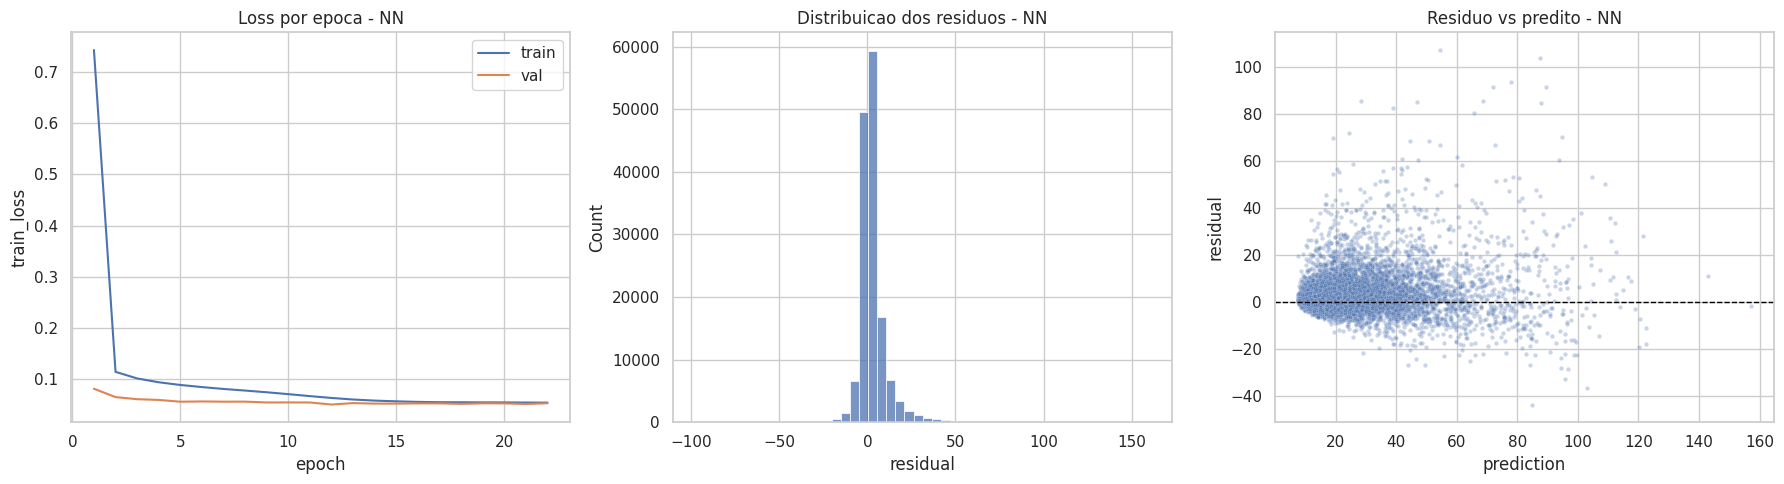

In [8]:
history_pdf = pd.DataFrame(history)
residual_pdf = eval_pdf.copy()
residual_pdf['residual'] = residual_pdf[TARGET_COL] - residual_pdf['prediction']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=history_pdf, x='epoch', y='train_loss', ax=axes[0], label='train')
sns.lineplot(data=history_pdf, x='epoch', y='val_loss', ax=axes[0], label='val')
axes[0].set_title('Loss por epoca - NN')
sns.histplot(residual_pdf['residual'], bins=50, ax=axes[1])
axes[1].set_title('Distribuicao dos residuos - NN')
sns.scatterplot(data=residual_pdf.sample(min(len(residual_pdf), 10000), random_state=SEED), x='prediction', y='residual', s=10, alpha=0.3, ax=axes[2])
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Residuo vs predito - NN')
plt.tight_layout()
plt.savefig(RESIDUAL_PLOT, dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Checkpoint completo: alem do state_dict, persistir feature_columns,
# scaler.mean_/scale_ e ordem dos NUMERIC_COLS habilita inferencia em
# uma maquina diferente sem reconstruir o pipeline manualmente.
torch.save({
    'state_dict': model.state_dict(),
    'feature_columns': feature_columns,
    'numeric_cols': list(NUMERIC_COLS),
    'categorical_cols': list(CATEGORICAL_COLS),
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'sample_rows_train': len(train_pdf),
    'sample_rows_test': len(test_pdf),
}, MODEL_OUTPUT)

results_df = append_metric(
    model='neural_network',
    rmse=metrics['rmse'],
    mae=metrics['mae'],
    r2=metrics['r2'],
    train_seconds=train_seconds,
    notes=f'PyTorch estratificado (Mar+Abr+Mai) train={len(train_pdf)} test={len(test_pdf)}',
)
results_df.tail(10)

,run_id,timestamp_utc,git_sha,model,rmse,mae,r2,train_seconds,notes
0,9fc930c0,2026-05-07T00:50:07,unknown,linear_regression,9.073593,5.758933,0.805620,241.497893,baseline com StandardScaler e one-hot encoding
1,f7052309,2026-05-07T01:20:27,unknown,decision_tree,8.909104,5.133254,0.812604,462.182026,DecisionTreeRegressor maxDepth=8 maxBins=256
2,c7448ac7,2026-05-07T01:25:39,unknown,neural_network,9.857471,6.894977,0.762050,79.739650,PyTorch em amostra train=200000 test=100000
3,ccb51264,2026-05-07T01:33:29,unknown,neural_network,9.506935,6.381533,0.778672,357.578796,PyTorch em amostra train=800000 test=100000
4,a14e4838,2026-05-07T01:50:01,unknown,neural_network,9.129682,4.724017,0.795889,821.350001,PyTorch em amostra train=1600000 test=100000
5,1a899ff4,2026-05-07T12:57:55,unknown,neural_network,11.621490,6.911168,0.679282,1158.965351,PyTorch em amostra train=2000000 test=200000
6,c6087345,2026-05-07T13:10:57,unknown,neural_network,9.621022,5.432433,0.785561,527.603079,PyTorch estratificado (Mar+Abr+Mai) train=1999...
7,f1f5d6bf,2026-05-07T13:21:55,unknown,neural_network,9.206591,5.029700,0.795846,521.755515,PyTorch estratificado (Mar+Abr+Mai) train=1279...


In [10]:
# spark.stop() ja chamado logo apos toPandas() para liberar RAM antes do treino.